In [ ]:
# DATASET INFO_LOTES

In [ ]:
# 1) Imports
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 2) Ruta
ruta = Path("..") / "dataset" / "info_lote.json"

# Verificación
print("Existe archivo?:", ruta.exists(), "| Ruta:", ruta)

# 3) Leer el JSON
with open(ruta, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Tipo dato:", type(data))


Existe archivo?: True | Ruta: ..\dataset\info_lote.json
Tipo dato: <class 'dict'>


In [ ]:
# Mostramos las claves principales
#print(f"Claves del JSON: {data.keys()}")
print(len(data))

list(data.keys())[:20]



69567


['G80V76K49J80T71',
 'G80V76K49L46V78M',
 'G80V76K49L48J80T71',
 'G80V76K49L49J80T71',
 'G80V76K49L50J80T71',
 'G80V76K49L51J80T71',
 'G80V76K49L52J80T71',
 'G80V76K49L53J80T71',
 'G80V76K49L54J80T71',
 'G80V76K49L55J80T71',
 'G80V76K49L56J80T71',
 'G80V76K49L57J80T71',
 'G80V76K49M46V78M',
 'G80V76K49M48J80T71',
 'G80V76K49M49J80T71',
 'G80V76K49M50J80T71',
 'G80V76K49M51J80T71',
 'G80V76K49M52J80T71',
 'G80V76K49M53J80T71',
 'G80V76K49M54J80T71']

In [ ]:
rows = []
for lote, lista in data.items():
    for item in lista:
        item["lote"] = lote  # añadimos la clave como nueva columna
        rows.append(item)

In [ ]:
# Creamos el DataFrame
df_info_lotes = pd.DataFrame(rows)
df_info_lotes.head(20)

,t_id,marca,coste_inicial,lote
0,Apple 1.png,ParaísoFrutal,2.642048,G80V76K49J80T71
1,Apple 10.png,TropicalSabor,1.702296,G80V76K49L46V78M
2,Apple 100.png,DeliciaNaturaleza,1.176703,G80V76K49L48J80T71
3,Apple 101.png,EmbrujoFrutal,2.314693,G80V76K49L49J80T71
4,Apple 102.png,ExóticoManjar,2.473541,G80V76K49L50J80T71
5,Apple 103.png,DeliciaNaturaleza,1.056429,G80V76K49L51J80T71
6,Apple 104.png,SinfoníaDelicias,1.770176,G80V76K49L52J80T71
7,Apple 105.png,EmbrujoFrutal,1.873714,G80V76K49L53J80T71
8,Apple 106.png,ExóticoManjar,2.196754,G80V76K49L54J80T71
9,Apple 107.png,PlacerFrutado,1.597692,G80V76K49L55J80T71


In [ ]:
#Información general
df_info_lotes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70549 entries, 0 to 70548
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   t_id           70549 non-null  object 
 1   marca          70549 non-null  object 
 2   coste_inicial  68538 non-null  float64
 3   lote           70549 non-null  object 
dtypes: float64(1), object(3)
memory usage: 2.2+ MB


In [ ]:
#dimension del DF
df_info_lotes.shape

(70549, 4)

In [ ]:
#tipo de datos para cada columna
df_info_lotes.dtypes

t_id              object
marca             object
coste_inicial    float64
lote              object
dtype: object

In [ ]:
#información sobre si tenemos datos nulos
df_info_lotes.isna().sum()

t_id                0
marca               0
coste_inicial    2011
lote                0
dtype: int64

In [ ]:
# solo tenemos un 2.85 % de los datos que son nulos en la columna coste_inicial. Hablamos de un valor inferior a 5% por tanto mínimo.
df_info_lotes.isna().mean() * 100

t_id             0.000000
marca            0.000000
coste_inicial    2.850501
lote             0.000000
dtype: float64

In [ ]:
#Comprobamos que los nulos tenga un nombre común para todos en este NaN
df_info_lotes[df_info_lotes["coste_inicial"].isna()].head()


,t_id,marca,coste_inicial,lote
41,Apple 136.png,DulceEncanto,NaN,G80V76K49O54J80T71
100,Apple 19.png,FrutaDulce,NaN,G80V76K49U46V78M
123,Apple 21.png,FiestaSabor,NaN,G80V76K50M46V78M
205,Apple 284.png,FantasíaDelicia,NaN,G80V76K50T52J80T71
223,Apple 30.png,VibranteSabores,NaN,G80V76K51L46V78M


In [ ]:
#Comprobamos si ha duplicados
df_info_lotes.duplicated().sum()


np.int64(0)

In [ ]:
#lectura general de los datos números que tenemos. Resumiendo tenemos unos datos muy simetricos entre si con poca variación
df_info_lotes.describe()


,coste_inicial
count,68538.000000
mean,1.999960
std,0.498413
min,0.022064
25%,1.661823
50%,1.999375
75%,2.337605
max,3.988367


In [ ]:

df_info_lotes[['t_id','marca','lote']].describe()

,t_id,marca,lote
count,70549,70549,70549
unique,69687,35,69567
top,scene02101.png,FrescoDelValle,C67K78K48O52L49J80T71
freq,5,2069,5


In [ ]:
# Observamos los outliers. Y aunque tiene un coste poco común podria deberse a un momento puntual de la ley de la oferta y la demanda
df_info_lotes[df_info_lotes["coste_inicial"] <= 0.2].head(11)

,t_id,marca,coste_inicial,lote
11276,Apple 0845.png,ArteFrutal,0.139266,G80V76K48T52Q46V78M
15442,Carambola 001645.png,DulzuraSilvestre,0.022064,I65B65S66U76G48L49R52Q46V78M
23562,GuavaÒÇé133 resized resized.png,SinfoníaDelicias,0.119227,M85G86G210I201M51O82K83O90K68B69C73J69J46V78M
24780,GuavaÒÇé1603 resized.png,EncantoNativo,0.161172,M85G86G210I201M54L51B69C73J69J46V78M
35650,Guava0693.png,RincónFrutas,0.152917,M85G86G48R57O46V78M
36128,Kiwi A001122.png,FrescuraInigualable,0.183452,Q73G73G48L49M50N46V78M
36141,Kiwi A001134.png,FrescoDelValle,0.152087,Q73G73G48L49M51P46V78M
40893,Kiwi001549.png,PaladarDorado,0.100438,Q73G73L48M53P57J80T71
47345,Mango00360.png,SabrosoEdén,0.159395,S65T71U48L51R48J80T71
62246,Pitaya00175.png,ExquisitoJardín,0.149162,V73D65I65L48M55Q46V78M


In [ ]:
# Observamos el mismo patrón con los outliers máximos.
df_info_lotes[df_info_lotes["coste_inicial"] >= 3.8].head(9)

,t_id,marca,coste_inicial,lote
18460,Guava159.png,CosechaDivina,3.848977,M85G86G49Q57J80T71
19817,1GuavaÒÇé2570.png,TesoroNaturaleza,3.839682,M71E65F65T199K50Q55L46V78M
31727,GuavaÒÇé941 resized.jpg,TropicalSabor,3.876357,M85G86G210I201U52M82K83O90K68J74V71
35584,Guava0633.png,ParaísoFrutal,3.849094,M85G86G48R51O46V78M
44028,Kiwi00614.png,ParaísoFrutal,3.873204,Q73G73L48R49P46V78M
46422,Mango00277.png,AventuraFrutal,3.873056,S65T71U48L50S55J80T71
53786,Peach001077.png,AventuraFrutal,3.988367,V69G67N48L49L55S46V78M
58896,pear_0_5101.png,PlacerFrutado,3.845743,V69G82O48O53M48M46V78M
68446,Tamotoes00106.png,RicoBosque,3.914585,D65S79D79K83L48M48R46V78M


In [ ]:

#fila con el coste mínimo
fila_min = df_info_lotes.loc[df_info_lotes["coste_inicial"].idxmin()]

#fila con el coste máximo
fila_max = df_info_lotes.loc[df_info_lotes["coste_inicial"].idxmax()]

print("--- Fila con Coste Mínimo ---")
print(fila_min)

print("\n--- Fila con Coste Máximo ---")
print(fila_max)


--- Fila con Coste Mínimo ---
t_id                     Carambola 001645.png
marca                        DulzuraSilvestre
coste_inicial                        0.022064
lote             I65B65S66U76G48L49R52Q46V78M
Name: 15442, dtype: object

--- Fila con Coste Máximo ---
t_id                    Peach001077.png
marca                    AventuraFrutal
coste_inicial                  3.988367
lote             V69G67N48L49L55S46V78M
Name: 53786, dtype: object


In [ ]:
# LAS SIGUIENTES COLUMNAS SE CENTRAN EN LOS DUPLICADOS DE LAS CELDAS:

In [ ]:
#df_info_lotes["t_id"].duplicated().sum()
#df_info_lotes["lote"].duplicated().sum()
#df_info_lotes["marca"].duplicated().sum()
df_info_lotes["coste_inicial"].duplicated().sum()

# Hemos observado las repeticiones que hay de cada columna

np.int64(2010)

In [ ]:
#df_info_lotes["lote"].nunique(), len(data) # valores únicos de una columna y la longitud total del df
df_info_lotes["t_id"].value_counts()[lambda s: s > 1].head(60) # aqui calculo el total de valores de una columna que sea superiores a 1
#df_info_lotes[df_info_lotes["lote"] == "C67K78K48O55L49J80T71"] # filtro por una fila concreta y miro si sale repetida y que patrones tiene



t_id
scene02101.png    5
scene00601.png    5
scene02301.png    5
scene02701.png    5
scene02901.png    5
scene01601.png    5
scene01501.png    5
scene03401.png    5
scene03601.png    5
scene01001.png    5
scene03701.png    5
scene00701.png    5
scene02201.png    5
scene06001.png    4
scene01201.png    4
scene00501.png    4
scene01401.png    4
scene01901.png    4
scene01301.png    4
scene04101.png    4
scene07701.png    4
scene01101.png    4
scene00201.png    4
scene05601.png    4
scene05701.png    4
scene03901.png    4
scene00901.png    4
scene05901.png    4
scene05801.png    4
scene03101.png    4
scene02001.png    4
scene00801.png    4
scene02501.png    4
scene07401.png    4
scene04401.png    4
scene02801.png    4
scene01801.png    4
scene05201.png    4
scene04501.png    4
scene06561.png    3
scene03981.png    3
scene03961.png    3
scene03441.png    3
scene06581.png    3
scene07881.png    3
scene03461.png    3
scene03681.png    3
scene03921.png    3
scene03621.png    3
scene03841.png 

In [ ]:
# sobre las columnas seleccionadas buscamos info
df_info_lotes[["lote", "t_id"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70549 entries, 0 to 70548
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   lote    70549 non-null  object
 1   t_id    70549 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [ ]:
# buscamos los repetidos solo teniendo en cuenta las dos columnas seleccionadas
df_info_lotes.duplicated(["t_id", "lote"]).sum()

np.int64(862)

In [ ]:
# Miramos de agrupar todos los t_id para ver si luego hay alguno que tuviese más 1 lote. En este caso todos los t_id tienen un lote
t_id_varios_lote = (
    df_info_lotes
    .groupby("t_id")["lote"]
    .nunique()
    .loc[lambda s: s > 1]
    .sort_values(ascending=False)
)

t_id_varios_lote.head(20)


Series([], Name: lote, dtype: int64)

In [ ]:
# Lo mismo que antes pero agrupamos por lote y miramos si un lote tiene más de un t_id de relación. En este caso tenemos lotes que tiene diferentes t_id

lote_varios_t_id = (
    df_info_lotes
    .groupby("lote")["t_id"]
    .nunique()
    .loc[lambda i: i > 1]
    .sort_values(ascending=False)
)

lote_varios_t_id.head()


lote
G80V76K69L48M46V78M       2
G80V76K69L48N46V78M       2
G80V76K69L54M50T46V78M    2
G80V76K69L54M50S46V78M    2
G80V76K69L54M50R46V78M    2
Name: t_id, dtype: int64

In [ ]:
coste_inicial_varios_lotes= (
    df_info_lotes
    .groupby("coste_inicial")["lote"]
    .nunique()
    .loc[lambda i: i > 1]
    .sort_values(ascending=False)
)

coste_inicial_varios_lotes.head(60)

# Agrupamos columna coste_inicial y miramos si tiene alguna coincidencia con la columna lote donde sea superior a 1.
# En este caso no hay repeticiones

Series([], Name: lote, dtype: int64)

In [ ]:
lote_varios_coste_inicial= (
    df_info_lotes
    .groupby("lote")["coste_inicial"]
    .nunique()
    .loc[lambda s: s > 1]
    .sort_values(ascending=False)
)

lote_varios_coste_inicial.head(60)

# Aqui agrupamos columna lote y miramos lo valores unicos de coste_inicial mayores a 1 y vemos que 1 lote puede tener diferentes coste_inicial

lote
C67K78K48O55L49J80T71    5
C67K78K48O54L49J80T71    5
C67K78K48M53L49J80T71    5
C67K78K48N57L49J80T71    5
C67K78K48M48L49J80T71    5
C67K78K48N51L49J80T71    5
C67K78K48N50L49J80T71    5
C67K78K48L54L49J80T71    5
C67K78K48N49L49J80T71    5
C67K78K48M54L49J80T71    5
C67K78K48O52L49J80T71    5
C67K78K48M50L49J80T71    4
C67K78K48P53L49J80T71    4
C67K78K48P52L49J80T71    4
C67K78K48M49L49J80T71    4
C67K78K48P49L49J80T71    4
C67K78K48L57L49J80T71    4
C67K78K48M51L49J80T71    4
C67K78K48N56L49J80T71    4
C67K78K48S52L49J80T71    4
C67K78K48L55L49J80T71    4
C67K78K48M56L49J80T71    4
C67K78K48M57L49J80T71    4
C67K78K48N48L49J80T71    4
C67K78K48S55L49J80T71    4
C67K78K48O49L49J80T71    4
C67K78K48N55L49J80T71    4
C67K78K48L56L49J80T71    4
C67K78K48M52L49J80T71    4
C67K78K48Q57L49J80T71    4
C67K78K48L53L49J80T71    4
C67K78K48Q50L49J80T71    4
C67K78K48L50L49J80T71    4
C67K78K48R48L49J80T71    4
C67K78K48Q55L49J80T71    4
C67K78K48Q54L49J80T71    4
C67K78K48Q53L49J80T71  

In [ ]:
# CONCLUSIÓN INICIAL TENEMOS UN DATAFRAME DE 4 COLUMNAS CON 70.549 FILAS.
# DE LAS CUALES EN LA COLUMNA COSTE INICIAL TENEMOS 2.011 DATOS NULOS (NaN)
# SE HA DETECTADO QUE EN LA RELACIÓN DE LAS COLUMNAS T_ID Y LOTE HAY:
# 862 FILAS QUE SE REPITE EL MISMO T_ID
# 982 FILAS QUE SE REPITE EL MISMO LOTE
# POR LO TANTO NOS LLEVA A LA CONCLUSIÓN QUE:
# 862 FILAS COMPARTEN MISMO T_ID Y LOTE
# Y APARTE DE LAS 862 ANTERIORES TENEMOS 120 FILAS ( 982 - 862) DE LOTE QUE TAMBIÉN SE REPITEN PERO TIENE DIFERENTE T_ID

# LAS OTRAS DOS COLUMNAS:
# MARCA TENEMOS EN TOTAL 35 VALORES ÚNICOS ES DECIR 35 MARCAS QUE SE REPEITEN EN LAS DIFERENTES FILAS
#En coste_inicial tenemos 68.538 valores no nulos,
#de los cuales 2.010 son repeticiones adicionales,
#resultando en 66.528 valores únicos reales. Y  tanto el min como el max son valores que se podrian deber a la ley de la oferta y la demanda
# HEMOS ENCONTRADO QUE UN LOTE PUEDE LLEGAR A TENER DIFERENTES COSTE_INICIAL.


In [ ]:
# DATASET LOTES

In [ ]:
# 2) Ruta
ruta_2 = Path("..") / "dataset" / "lotes.json"

# Verificación
print("Existe archivo?:", ruta_2.exists(), "| Ruta:", ruta_2)

# 3) Leer el JSON
with open(ruta_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

print("Tipo dato:", type(data_2))


Existe archivo?: True | Ruta: ..\dataset\lotes.json
Tipo dato: <class 'dict'>


In [ ]:
# Mostramos las claves principales
#print(f"Claves del JSON: {data_2.keys()}")
print(len(data_2))

list(data_2.keys())[:2]

69687


['Apple 1.png', 'Apple 10.png']

In [ ]:
# Creamos el Dataframe
df_lotes= pd.DataFrame(list(data_2.items()), columns=["t_id", "lote"])


In [ ]:
# Observamos el DF
df_lotes.head(20)

,t_id,lote
0,Apple 1.png,G80V76K49J80T71
1,Apple 10.png,G80V76K49L46V78M
2,Apple 100.png,G80V76K49L48J80T71
3,Apple 101.png,G80V76K49L49J80T71
4,Apple 102.png,G80V76K49L50J80T71
5,Apple 103.png,G80V76K49L51J80T71
6,Apple 104.png,G80V76K49L52J80T71
7,Apple 105.png,G80V76K49L53J80T71
8,Apple 106.png,G80V76K49L54J80T71
9,Apple 107.png,G80V76K49L55J80T71


In [ ]:
#Información general
df_lotes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69687 entries, 0 to 69686
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   t_id    69687 non-null  object
 1   lote    69687 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [ ]:
df_lotes.dtypes

t_id    object
lote    object
dtype: object

In [ ]:
# Observamos la forma del DF
df_lotes.shape

(69687, 2)

In [ ]:
# Buscamos valores nulos
df_lotes.isna().sum()

t_id    0
lote    0
dtype: int64

In [ ]:
# Buscamos duplicados en este caso de todas las columnas sin separar. Es decir si un valor repite en un columna varias veces pero en la otra es diferente marca que no es duplicado
df_lotes.duplicated().sum()

np.int64(0)

In [ ]:
# Observamos con describe que nos da info diferente a la normal a solo ser valores de tipo object
df_lotes.describe()

,t_id,lote
count,69687,69687
unique,69687,69567
top,Apple 1.png,G80V76K69L51R53J80T71
freq,1,2


In [ ]:
# Aqui buscamos duplicados por cada columna y observamos que si hay en la columna lote ( 120)

#df_lotes["t_id"].duplicated().sum()
df_lotes["lote"].duplicated().sum()

np.int64(120)

In [ ]:
# En la columna lote miramos la cantidad de veces que se repiten los valores duplicados
df_lotes["lote"].value_counts()[lambda s: s > 1].head()

lote
G80V76K69L51R53J80T71     2
G80V76K69L53U57J80T71     2
G80V76K69L54M50S46V78M    2
G80V76K69L54M50R46V78M    2
G80V76K69L54M50Q46V78M    2
Name: count, dtype: int64

In [ ]:
df_lotes["lote"].nunique(), len(data_2)

(69567, 69687)

In [ ]:
# CONCLUSIÓN FINAL  TENEMOS 2 COLUMNAS EN LA DATAFRAME
# TENEMOS LA COLUMNA t_id Y LA COLUMNA lote
# CON UNA CANTIDAD TOTAL DE FILAS DE: 69687
# NO TENEMOS NULOS
# PERO SI QUE TENEMOS EN LA COLUMNA lote 120 REPETICIONES. lO QUE SIGNIFICA QUE TENEMOS 69567 VALORES UNICOS

In [ ]:
# DATASET PROVEEDORES

In [ ]:
# 2) Ruta
ruta_3 = Path("..") / "dataset" / "proveedores.json"

# Verificación
print("Existe archivo?:", ruta_3.exists(), "| Ruta:", ruta_3)

# 3) Leer el JSON
with open(ruta_3, "r", encoding="utf-8") as f:
    data_3 = json.load(f)

print("Tipo dato:", type(data_3))

Existe archivo?: True | Ruta: ..\dataset\proveedores.json
Tipo dato: <class 'dict'>


In [ ]:
# Mostramos las claves principales
#print(f"Claves del JSON: {data_3.keys()}")
print(len(data_3))

list(data_3.keys())[:2]

35


['Agricultura Inteligente TechCultivos', 'Semillero Genético BioCampo']

In [ ]:
# Creamos una lista con las columnas que necesitamos en el DF
rows_3 = []
for proveedor, lista in data_3.items():
    for item in lista:
        item["proveedor"] = proveedor  # añadimos la clave como nueva columna
        rows_3.append(item)

In [ ]:
# Creamos el DataFrame
df_proveedores = pd.DataFrame(rows_3)
df_proveedores.head(20)
#df_proveedores.tail()
#df_proveedores.sample(5)

,t_id,proveedor
0,Apple 1.png,Agricultura Inteligente TechCultivos
1,Apple 109.png,Agricultura Inteligente TechCultivos
2,Apple 205.png,Agricultura Inteligente TechCultivos
3,Apple 240.png,Agricultura Inteligente TechCultivos
4,Apple 25.png,Agricultura Inteligente TechCultivos
5,Apple 253.png,Agricultura Inteligente TechCultivos
6,Apple 329.png,Agricultura Inteligente TechCultivos
7,Apple 389.png,Agricultura Inteligente TechCultivos
8,Apple 467.png,Agricultura Inteligente TechCultivos
9,Apple 490.png,Agricultura Inteligente TechCultivos


In [ ]:
#Tipo de dato
df_proveedores.dtypes

t_id         object
proveedor    object
dtype: object

In [ ]:
# Info general del DF
df_proveedores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70549 entries, 0 to 70548
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   t_id       70549 non-null  object
 1   proveedor  70549 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [ ]:
# Forma del DF
df_proveedores.shape

(70549, 2)

In [ ]:
# Buscamos nulos. NO hay
df_proveedores.isna().sum()

t_id         0
proveedor    0
dtype: int64

In [ ]:
df_proveedores.describe()

,t_id,proveedor
count,70549,70549
unique,69687,35
top,scene03401.png,Agronutrientes del Futuro
freq,5,2077


In [ ]:
# Duplicados en todas las columnas. Hay 25 coincidencias.
df_proveedores.duplicated().sum()

np.int64(25)

In [ ]:
# Duplicados de la columna t_id
df_proveedores["t_id"].duplicated().sum()

np.int64(862)

In [ ]:
# Duplicados de la columna proveedor
df_proveedores["proveedor"].duplicated().sum()

np.int64(70514)

In [ ]:
# Filtrando la columna t_id miramos las filas que existen más de una vez
df_proveedores["t_id"].value_counts()[lambda s: s > 1].head(10)

t_id
scene03401.png    5
scene03601.png    5
scene02901.png    5
scene03701.png    5
scene01601.png    5
scene00701.png    5
scene02201.png    5
scene00601.png    5
scene02301.png    5
scene01501.png    5
Name: count, dtype: int64

In [ ]:
# Filtramos el dataframe para que solo muestre las filas que son clones exactos
# keep=False hace que nos muestre tanto el original como sus copias
ids_repetidos = df_proveedores[df_proveedores.duplicated(keep=False)]["t_id"].unique()

print(ids_repetidos)

# Aqui estan los 25 casos del duplicated del DF

['scene06481.png' 'scene06021.png' 'scene10561.png' 'scene11821.png'
 'scene11741.png' 'scene05601.png' 'scene05021.png' 'scene02521.png'
 'scene07361.png' 'scene02241.png' 'scene02761.png' 'scene02461.png'
 'scene00341.png' 'scene02901.png' 'scene01601.png' 'scene10081.png'
 'scene00661.png' 'scene10961.png' 'scene07461.png' 'scene01401.png'
 'scene00501.png' 'scene12541.png' 'scene10841.png' 'scene00801.png'
 'scene00461.png']


In [ ]:
# Con esta línea de código filtamos por la columna t_id buscando un valor especifico. Nos ayuda a comprobar los resultados del bloque anterior
df_proveedores[df_proveedores["t_id"] == "scene02901.png"]

,t_id,proveedor
18156,scene02901.png,Avícola San José
40325,scene02901.png,Energía Renovable AgroSol
40824,scene02901.png,Energía Renovable AgroSol
54549,scene02901.png,Cosechadoras Progresivas SA
60713,scene02901.png,Tractores Eficientes Delgado


In [ ]:
# Mismo código que el anterior pero para observar los diferentes resultados.
df_proveedores[df_proveedores["t_id"] == "scene10841.png"]

,t_id,proveedor
60606,scene10841.png,Tractores Eficientes Delgado
61054,scene10841.png,Tractores Eficientes Delgado


In [ ]:
#CONLCUSIÓN
# TENEMOS UN DATAFRAME DE DOS COLUMNAS CON UN TOTAL DE 70549 FILAS
# NO TENEMOS NULOS
# DUPLICADOS TENEMOS QUE EN 25 OCASIONES SE REPITEN LOS MISMO VALORES EN AMBAS COLUMNAS ( TENER EN CUENTA SI SON VALORES DUPLICADOS).
# DE MOMENTO NO ELIMINO NADA YA QUE SIN ADELANTARNOS A NADA PODRIAN SER DIFERENTES COMPRAS ( DIGO ESTO SIN CONOCIMIENTO DE LAS COMPRAS)
# EN t_id TENEMOS 862 VALORES QUE SE REPITEN.
# EN LA COLUMNA proveedor PARA SIMPLIFICAR TENENMOS 35 VALORES UNICOS QUE SE REPITEN EN LAS DIFERENTES FILAS

In [ ]:
# DATASET PROVEEDORES-CLIENTES

In [ ]:
# 2) Ruta
ruta_4 = Path("..") / "dataset" / "proveedores-clientes.json"

# Verificación
print("Existe archivo?:", ruta_4.exists(), "| Ruta:", ruta_4)

# 3) Leer el JSON
with open(ruta_4, "r", encoding="utf-8") as f:
    data_4 = json.load(f)

print("Tipo dato:", type(data_4))

Existe archivo?: True | Ruta: ..\dataset\proveedores-clientes.json
Tipo dato: <class 'dict'>


In [ ]:
# Creamos una lista para los nombres de las columnas del DF
rows_4 = []

for proveedor, lista in data_4.items():
    for item in lista:
        # item = ["image12.png", "CompraMaestra"] ejemplo de lógica al indexar
        t_id = item[0] if len(item) > 0 else None
        cliente = item[1] if len(item) > 1 else None

        rows_4.append({
            "proveedor": proveedor,
            "t_id": t_id,
            "cliente": cliente
        })


In [ ]:
# Creamos el DF y observamos como se representa
df_proveedores_clientes = pd.DataFrame(rows_4)
df_proveedores_clientes.head(20)
#df_proveedores_clientes.tail(20)
#df_proveedores_clientes.sample(20)

,proveedor,t_id,cliente
0,Agricultura Inteligente TechCultivos,Apple 1.png,CompraMaestra
1,Agricultura Inteligente TechCultivos,Apple 109.png,Almacén Estrella
2,Agricultura Inteligente TechCultivos,Apple 205.png,EcoMercado Sostenible
3,Agricultura Inteligente TechCultivos,Apple 240.png,Cosecha Fresca
4,Agricultura Inteligente TechCultivos,Apple 25.png,Central de Abastos Central
5,Agricultura Inteligente TechCultivos,Apple 253.png,El Bazar de la Comida
6,Agricultura Inteligente TechCultivos,Apple 329.png,Alimentación Total
7,Agricultura Inteligente TechCultivos,Apple 389.png,El Bazar de la Comida
8,Agricultura Inteligente TechCultivos,Apple 467.png,Distribuidora Alfa
9,Agricultura Inteligente TechCultivos,Apple 490.png,La Gran Cosecha


In [ ]:
# tipo de dato de las columnas
df_proveedores_clientes.dtypes

proveedor    object
t_id         object
cliente      object
dtype: object

In [ ]:
# Información general del DF
df_proveedores_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70549 entries, 0 to 70548
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   proveedor  70549 non-null  object
 1   t_id       70549 non-null  object
 2   cliente    70549 non-null  object
dtypes: object(3)
memory usage: 1.6+ MB


In [ ]:
df_proveedores_clientes.shape

(70549, 3)

In [ ]:
# Buscamos nulos. No hay
df_proveedores_clientes.isna().sum()

proveedor    0
t_id         0
cliente      0
dtype: int64

In [ ]:
# Hacemos un describe para ver la moda la frecuencia y los valores únicos de cada columna
df_proveedores_clientes.describe()

,proveedor,t_id,cliente
count,70549,70549,70549
unique,35,69687,34
top,Agronutrientes del Futuro,scene03401.png,SuperMercado Ideal
freq,2077,5,2129


In [ ]:
# Buscamos duplicados en todas las columnas no hay coincidencias
df_proveedores_clientes.duplicated().sum()

np.int64(0)

In [ ]:
# Buscamos duplicados filtrando por columna proveedor. Efectivamente tenemos
df_proveedores_clientes["proveedor"].duplicated().sum()

np.int64(70514)

In [ ]:
# Buscamos igual duplicados en t_id y también hay
df_proveedores_clientes["t_id"].duplicated().sum()

np.int64(862)

In [ ]:
# Mi proceso que los dos anteriores pero en la columna cliente
df_proveedores_clientes["cliente"].duplicated().sum()

np.int64(70515)

In [ ]:
#Línea para filtrar en este caso por t_id en un caso en concreto. Esta linea la utilizo para ir probando las diferentes situaciones que voy observando en el EDA
df_proveedores_clientes[df_proveedores_clientes["t_id"] == "scene01201.png"]

,proveedor,t_id,cliente
16273,Pecuaria Moderna Alcaraz,scene01201.png,Distribuciones del Sol
18210,Avícola San José,scene01201.png,MegaAhorro
20588,Fertilizantes Naturales del Valle,scene01201.png,Tienda Familiar
54476,Cosechadoras Progresivas SA,scene01201.png,Comercial Fresco


In [ ]:
# Agrupo por proveedor y cliente para observar la cantidad de t_id por dicha agrupación
df_proveedores_clientes.groupby(["proveedor","cliente"])["t_id"].count()

proveedor                             cliente                   
Agricultura Inteligente TechCultivos  Alimentación Total            73
                                      Alimentos Premium             66
                                      Almacén Estrella              54
                                      Central de Abastos Central    67
                                      Comercial Fresco              64
                                                                    ..
Vivero Verde Esperanza                SuperOfertas Plus             64
                                      SuperValle Verde              51
                                      Supermercados del Valle       59
                                      Tienda Familiar               64
                                      Tienda Selecta                67
Name: t_id, Length: 1190, dtype: int64

In [ ]:
'''
# Represento con un heatmap en plotly para acabar de visualizar mejor y ver la distribución de los movimientos
fig = px.imshow(
    tabla,
    labels=dict(x="Cliente", y="Proveedor", color="Cantidad de t_id"),
    title="Heatmap: nº de t_id por Proveedor vs Cliente",
    aspect="auto"
)

fig.update_yaxes(tickmode="linear")
fig.update_xaxes(tickmode="linear")

fig.update_layout(width=1400, height=800)
fig.show()
'''

'\n# Represento con un heatmap en plotly para acabar de visualizar mejor y ver la distribución de los movimientos\nfig = px.imshow(\n    tabla,\n    labels=dict(x="Cliente", y="Proveedor", color="Cantidad de t_id"),\n    title="Heatmap: nº de t_id por Proveedor vs Cliente",\n    aspect="auto"\n)\n\nfig.update_yaxes(tickmode="linear")  \nfig.update_xaxes(tickmode="linear")  \n\nfig.update_layout(width=1400, height=800)\nfig.show()\n'

In [ ]:
# Busco ver la relación que hay entre proveedor - cliente. En este caso es 1-N y siendo más concretos cada proveedor vende a todos los posibles clientes que hay
clientes_por_proveedor = df_proveedores_clientes.groupby("proveedor")["cliente"].nunique().sort_values(ascending=False)
print(clientes_por_proveedor)


proveedor
Agricultura Inteligente TechCultivos    34
Reforestación Ecológica VerdeVida       34
Insecticidas Ecológicos Reyes           34
Mallas AgroProtección García            34
Maquinaria Agrícola Avanzada            34
Pecuaria Moderna Alcaraz                34
Pesca Sustentable Oceanica              34
Productos Lácteos EcoLeche              34
RiegoSmart Innovación                   34
Ganadería Orgánica TierraFértil         34
Semillas Innovadoras S.A.               34
Semillero Genético BioCampo             34
Silos y Almacenes AgroVault             34
Tecnosembradoras del Sur                34
Tractores Eficientes Delgado            34
Veterinaria EcoAnimal                   34
Herramientas Agroindustriales Gómez     34
Fitosanitarios BioPro                   34
AgroEnvases Sostenibles                 34
Avícola San José                        34
AgroQuímicos Naturales BioCultivos      34
AgroSoftware Soluciones                 34
AgroSuministros del Campo               34
A

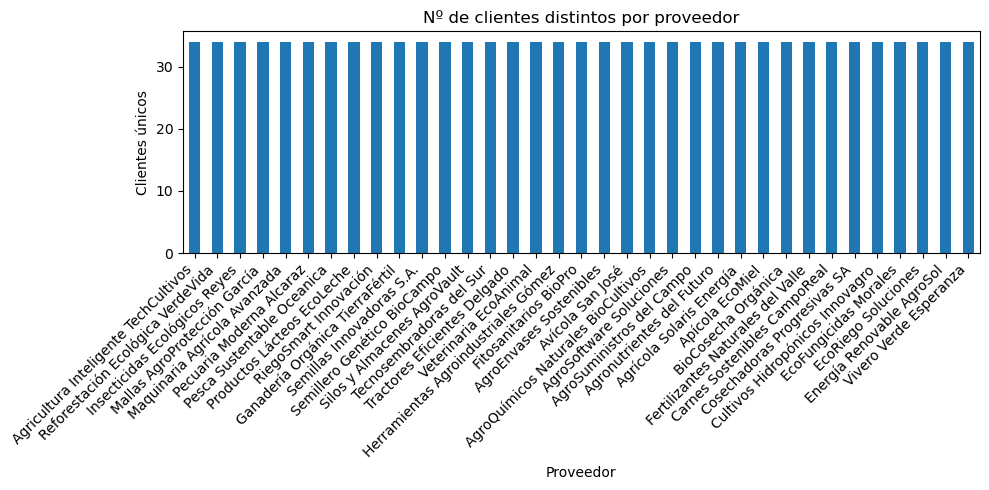

In [ ]:
#Visualizamos con un barplot
plt.figure(figsize=(10, 5))
clientes_por_proveedor.plot(kind="bar")
plt.title("Nº de clientes distintos por proveedor")
plt.xlabel("Proveedor")
plt.ylabel("Clientes únicos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Mismo situación que antes pero cliente-proveedor. Y pasa igual es 1-N por cada cliente hay diversos proveedores y aplica el mismo caso anterior. Cada cliente tiene relación con todos los proveedores
proveedores_por_cliente = df_proveedores_clientes.groupby("cliente")["proveedor"].nunique().sort_values(ascending=False)
print(proveedores_por_cliente)


cliente
Alimentación Total            35
Mercado del Barrio            35
La Tienda Justa               35
MaxiAlimentos                 35
MaxiDescuentos                35
MegaAhorro                    35
MegaCompra                    35
Mercado Fresco XYZ            35
SuperAhorro Express           35
Alimentos Premium             35
SuperEconómico                35
SuperMercado Ideal            35
SuperOfertas Plus             35
SuperValle Verde              35
Supermercados del Valle       35
Tienda Familiar               35
La Ruta del Sabor             35
La Gran Cosecha               35
La Canasta Feliz              35
El Bazar de la Comida         35
EcoTienda                     35
EcoMercado Sostenible         35
Distribuidora Nacional        35
Distribuidora Gourmet         35
Distribuidora Alfa            35
Distribuciones del Sol        35
Delicias del Campo            35
Cosecha Fresca                35
CompraRápida                  35
CompraMaestra                 35
Co

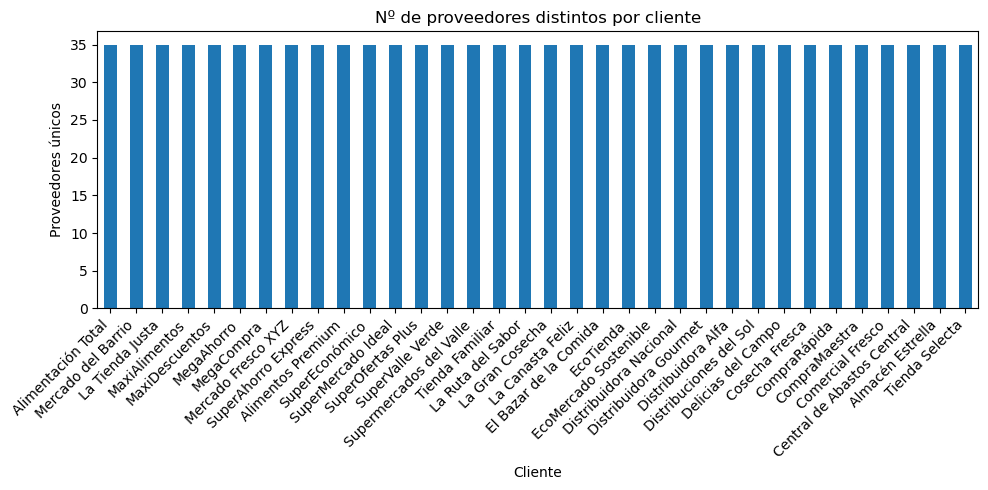

In [ ]:
#Visualizamos con un barplot
plt.figure(figsize=(10, 5))
proveedores_por_cliente.plot(kind="bar")
plt.title("Nº de proveedores distintos por cliente")
plt.xlabel("Cliente")
plt.ylabel("Proveedores únicos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Continuamos verificando los proveedores. Observamos que un mismo t_id puede apuntar a varios proveedores
tids_multi_proveedor = (
    df_proveedores_clientes.groupby("t_id")["proveedor"].nunique()
      .sort_values(ascending=False)
)

tids_multi_proveedor[tids_multi_proveedor > 1].head(30)


t_id
scene03701.png    5
scene03601.png    5
scene00601.png    5
scene02101.png    5
scene02701.png    5
scene00701.png    5
scene01501.png    5
scene03401.png    5
scene02201.png    5
scene01001.png    5
scene02301.png    5
scene03901.png    4
scene02001.png    4
scene01801.png    4
scene05901.png    4
scene02901.png    4
scene05801.png    4
scene01901.png    4
scene05201.png    4
scene00901.png    4
scene01601.png    4
scene04101.png    4
scene01101.png    4
scene02801.png    4
scene05701.png    4
scene07401.png    4
scene06001.png    4
scene01301.png    4
scene07701.png    4
scene03101.png    4
Name: proveedor, dtype: int64

In [ ]:
# Igual que en el caso anterior. Un mismo t_id puede apuntar a diferentes clientes
tids_multi_cliente = (
    df_proveedores_clientes.groupby("t_id")["cliente"].nunique()
      .sort_values(ascending=False)
)

tids_multi_cliente[tids_multi_cliente > 1].head(20)


t_id
scene00701.png    5
scene02901.png    5
scene02101.png    5
scene03701.png    5
scene00601.png    5
scene03601.png    5
scene01601.png    5
scene01501.png    5
scene02801.png    4
scene01401.png    4
scene00201.png    4
scene03401.png    4
scene04401.png    4
scene02501.png    4
scene04501.png    4
scene00801.png    4
scene07401.png    4
scene05201.png    4
scene01201.png    4
scene02701.png    4
Name: cliente, dtype: int64

In [ ]:
#CONCLUSIÓN
#TENEMOS UN DATEFRAME DE 3 COLUMNAS
#HAY UN TOTAL DE 70549 FILAS
#COLUMNA PROVEEDOR TENEMOS 35 VALORES ÚNICOS
#COLUMNA CLIENTE TENEMOS 34 VALORES ÚNICOS
#COLUMNA t_id  TENEMOS 69687 VALORES ÚNICOS
#LA RELACIÓN PROVEEDOR-CLIENTE 1-N AL IGUAL QUE LA RELACIÓN CLIENTE-PROVEEDOR 1-N
# Cada cliente recibe producto de todos los posibles proveedores (35)
# Cada proveedor distrubuye producte a todos los posibles clientes (34)
#UN MISMO t_id PUEDE TENER DIFERENTES PROVEEDORES Y DIFERENTES CLIENTES.TAMBIÉN EN OCASIONES PUEDE COINCIDIR PROVEEDOR y t_id PERO DIFERENTE CLIENTE O VICEVERSA



In [ ]:
# DATASET TIPO

In [ ]:
# 2) Ruta
ruta_5 = Path("..") / "dataset" / "tipo.json"

# Verificación
print("Existe archivo?:", ruta_5.exists(), "| Ruta:", ruta_5)

# 3) Leer el JSON
with open(ruta_5, "r", encoding="utf-8") as f:
    data_5 = json.load(f)

print("Tipo dato:", type(data_5))

Existe archivo?: True | Ruta: ..\dataset\tipo.json
Tipo dato: <class 'dict'>


In [ ]:
# Creamos una lista con las columnas que necesitamos en el DF
rows_5 = []
for tipo, lista in data_5.items():
    for item in lista:
        item["tipo"] = tipo  # añadimos la clave como nueva columna
        rows_5.append(item)

In [ ]:
# Creamos el DataFrame
df_tipo = pd.DataFrame(rows_5)
df_tipo.head(20)
#df_tipo.tail()
#df_tipo.sample(5)

,t_id,tipo,tiempo_recogida
0,Apple 1.png,Apple,433
1,Apple 10.png,Apple,252
2,Apple 100.png,Apple,442
3,Apple 101.png,Apple,647
4,Apple 102.png,Apple,418
5,Apple 103.png,Apple,180
6,Apple 104.png,Apple,437
7,Apple 105.png,Apple,422
8,Apple 106.png,Apple,637
9,Apple 107.png,Apple,285


In [ ]:
# Tipo de dato de las columnas del DF
df_tipo.dtypes

t_id               object
tipo               object
tiempo_recogida     int64
dtype: object

In [ ]:
# Forma del DF
df_tipo.shape

(70549, 3)

In [ ]:
# Informacion general sobre el DF
df_tipo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70549 entries, 0 to 70548
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   t_id             70549 non-null  object
 1   tipo             70549 non-null  object
 2   tiempo_recogida  70549 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


In [ ]:
# Describe de la columna numerica ( tiempo_recogida)
df_tipo.describe()

,tiempo_recogida
count,70549.000000
mean,360.511134
std,207.344254
min,2.000000
25%,182.000000
50%,360.000000
75%,539.000000
max,719.000000


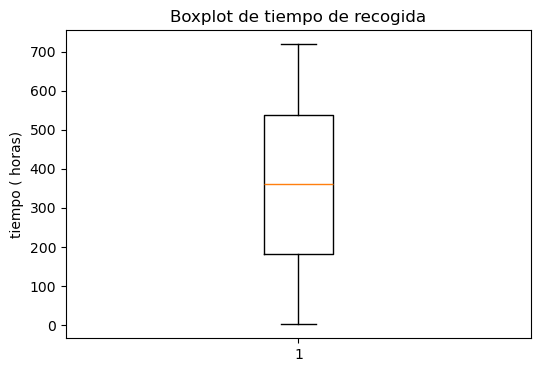

In [ ]:
#Visualizamos un boxplot para ver las distribución
plt.figure(figsize=(6,4))
plt.boxplot(df_tipo["tiempo_recogida"].dropna())
plt.title("Boxplot de tiempo de recogida")
plt.ylabel("tiempo ( horas)")
plt.show()

In [ ]:
# No tenemos nulos
df_tipo.isna().sum()

t_id               0
tipo               0
tiempo_recogida    0
dtype: int64

In [ ]:
# Buscamos duplicados en todo el DF pero no hay coincidentes en las 3 columnas
df_tipo.duplicated().sum()

np.int64(0)

In [ ]:
# Tenemos duplicados los mismo que los otros datasets
df_tipo["t_id"].duplicated().sum()

np.int64(862)

In [ ]:
# Del tipo hay muchos duplicados ya que tenemos solo 15 tipos frutas
df_tipo["tipo"].duplicated().sum()

np.int64(70534)

In [ ]:
# Sobre tiempo_recogida es normal que coincidan muchos valores ya que es númerico
df_tipo["tiempo_recogida"].duplicated().sum()

np.int64(69831)

In [ ]:
# Hacemos describe de las columnas categoricas
df_tipo[["tipo","t_id"]].describe()

,tipo,t_id
count,70549,70549
unique,15,69687
top,Guava,scene02101.png
freq,19698,5


In [ ]:
# Filtramos en la columna t_id para buscar un valor en particular. A raíz de esto observamos que un mismo t_id aplica a diferente tipo de fruta
df_tipo[df_tipo["t_id"] == "scene02101.png"]

,t_id,tipo,tiempo_recogida
1276,scene02101.png,Apple,519
1971,scene02101.png,Apple,238
3413,scene02101.png,Apple,244
5943,scene02101.png,Apple,565
17226,scene02101.png,Guava,230


In [ ]:
# Creamos la variable agrupando por t_id para filtrar por tipo y encontrar los valores unicos mayores a 1. Encontramos algo particular
# 512 t_id los llamamos conflictivos por son iguales pero apuntan a tipo de fruta diferente. En este caso la divergencia existe al parecer solo entre
# Apple y Guava

tids_conflictivos = (
    df_tipo.groupby("t_id")["tipo"]
    .nunique()
    .sort_values(ascending=False)
)

len(tids_conflictivos[tids_conflictivos > 1])


512

In [ ]:
# Buscamos las filas afectadas con el caso anterior y hallamos 1278 casos.

tids_problematicos = tids_conflictivos[tids_conflictivos > 1].index
filas_afectadas = df_tipo[df_tipo["t_id"].isin(tids_problematicos)].shape[0]
filas_afectadas


1278

In [ ]:
# Confirmamos que la divergencia que existe de t_id apunta al tipo fruta Apple y Guava
frutas_por_tid = (
    df_tipo[df_tipo["t_id"].isin(tids_problematicos)]
    .groupby("t_id")["tipo"]
    .unique()
)

frutas_por_tid.sample(20)


t_id
scene06581.png    [Apple, Guava]
scene04501.png    [Apple, Guava]
scene01141.png    [Apple, Guava]
scene11621.png    [Apple, Guava]
scene00341.png    [Apple, Guava]
scene08261.png    [Apple, Guava]
scene12441.png    [Apple, Guava]
scene00401.png    [Apple, Guava]
scene05161.png    [Apple, Guava]
scene09001.png    [Apple, Guava]
scene07361.png    [Apple, Guava]
scene01921.png    [Apple, Guava]
scene05301.png    [Apple, Guava]
scene08421.png    [Apple, Guava]
scene13381.png    [Apple, Guava]
scene07421.png    [Apple, Guava]
scene09801.png    [Apple, Guava]
scene03101.png    [Apple, Guava]
scene10721.png    [Apple, Guava]
scene07941.png    [Apple, Guava]
Name: tipo, dtype: object

In [ ]:
#CONCLUSIÓN
#TENEMOS UN DATEFRAME DE COLUMNAS CON 70549 FILAS.
# LA COLUMNA t_id TIENE 862 VALORES QUE SE REPITEN
# LA COLUMNA TIPO TIENE 15 VALORES ÚNICOS
# LA COLUMNA tiempo_recogida AL SER NUMERICA HAY MUCHOS VALORES COINCIDENTES
# COMO DATO A TENER EN CUENTA ES QUE HEMOS OBSERVADO QUE HAY 512 t_id QUE APUNTAN A DIFERENTES FRUTAS en este caso a APPLE y GUAVA. Y afecta a 1278 filas.

In [ ]:
# DATASET VENTA EN CLIENTE

In [ ]:
# 2) Ruta
ruta_6 = Path("..") / "dataset" / "venta_en_cliente.json"

# Verificación
print("Existe archivo?:", ruta_6.exists(), "| Ruta:", ruta_6)

# 3) Leer el JSON
with open(ruta_6, "r", encoding="utf-8") as f:
    data_6 = json.load(f)

print("Tipo dato:", type(data_6))

Existe archivo?: True | Ruta: ..\dataset\venta_en_cliente.json
Tipo dato: <class 'dict'>


In [ ]:
# Observamos las keys para hacernos una idea de los valores que contiene
print(len(data_6))

list(data_6.keys())[:34]

34


['CompraMaestra',
 'La Tienda Justa',
 'Supermercados del Valle',
 'Tienda Familiar',
 'SuperEconómico',
 'Tienda Selecta',
 'MaxiDescuentos',
 'Mercado del Barrio',
 'Alimentación Total',
 'Almacén Estrella',
 'CompraRápida',
 'La Ruta del Sabor',
 'La Gran Cosecha',
 'SuperAhorro Express',
 'EcoMercado Sostenible',
 'EcoTienda',
 'El Bazar de la Comida',
 'SuperMercado Ideal',
 'Comercial Fresco',
 'Distribuciones del Sol',
 'Mercado Fresco XYZ',
 'MegaCompra',
 'SuperOfertas Plus',
 'Distribuidora Gourmet',
 'Distribuidora Nacional',
 'Delicias del Campo',
 'La Canasta Feliz',
 'MaxiAlimentos',
 'Central de Abastos Central',
 'SuperValle Verde',
 'Distribuidora Alfa',
 'MegaAhorro',
 'Alimentos Premium',
 'Cosecha Fresca']

In [ ]:
# Creamos una lista con las columnas para el DF
rows_6 = []
for cliente, lista in data_6.items():
    for item in lista:
        item["cliente"] = cliente  # añadimos la clave como nueva columna
        rows_6.append(item)

In [ ]:
# Creamos el DF
df_venta_en_cliente = pd.DataFrame(rows_6)
df_venta_en_cliente.head(20)
#df_venta_en_cliente.tail()
#df_venta_en_cliente.sample(5)

,t_id,tiempo_venta,precio_venta,peso,cliente
0,Apple 1.png,437.0,4.909680,264.195357,CompraMaestra
1,Apple 10.png,259.0,3.425103,141.647327,CompraMaestra
2,Apple 135.png,388.0,3.468746,516.167670,CompraMaestra
3,Apple 218.png,484.0,4.345632,267.665780,CompraMaestra
4,Apple 304.png,638.0,3.709716,326.369599,CompraMaestra
5,Apple 334.png,194.0,1.727207,316.933819,CompraMaestra
6,Apple 348.png,547.0,3.768937,197.312890,CompraMaestra
7,Apple 364.png,716.0,2.887518,429.891711,CompraMaestra
8,Apple 412.png,444.0,3.356964,371.100967,CompraMaestra
9,Apple 426.png,449.0,3.607753,104.074941,CompraMaestra


In [ ]:
# Observamos el tipo de dato de cada columna
df_venta_en_cliente.dtypes

t_id             object
tiempo_venta    float64
precio_venta    float64
peso            float64
cliente          object
dtype: object

In [ ]:
# La forma del DF
df_venta_en_cliente.shape

(70549, 5)

In [ ]:
# Obtenemos información básica del DF
df_venta_en_cliente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70549 entries, 0 to 70548
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   t_id          70549 non-null  object 
 1   tiempo_venta  70326 non-null  float64
 2   precio_venta  69855 non-null  float64
 3   peso          70549 non-null  float64
 4   cliente       70549 non-null  object 
dtypes: float64(3), object(2)
memory usage: 2.7+ MB


In [ ]:
# Tenemos valores nulos en dos columnas en este caso columnas númericas
df_venta_en_cliente.isna().sum()

t_id              0
tiempo_venta    223
precio_venta    694
peso              0
cliente           0
dtype: int64

In [ ]:
# En porcentaje tenemos un 0,32 % y un 0,98% de datos nulos sobre el total. Es decir una cantidad poco significativa ya que no llegan al 5%
# donde podriamos plantear un escenario donde los datos podrian ser sesgados por estas filas
df_venta_en_cliente.isna().mean() * 100

t_id            0.000000
tiempo_venta    0.316092
precio_venta    0.983713
peso            0.000000
cliente         0.000000
dtype: float64

In [ ]:
# Comprobamos que los los Nulos contengan el mismo valor NaN
df_venta_en_cliente[df_venta_en_cliente["tiempo_venta"].isna()].sample(25)

,t_id,tiempo_venta,precio_venta,peso,cliente
62219,Tamotoes00269.png,NaN,2.108186,224.875947,SuperValle Verde
9788,Muskmelon 00709.png,NaN,3.248184,307.860999,SuperEconómico
47692,PlumÒÇé1069.png,NaN,4.157521,113.340734,SuperOfertas Plus
26947,Tamotoes00442.png,NaN,3.576145,473.713252,La Gran Cosecha
24652,Pitaya001223.png,NaN,4.122875,360.163497,La Ruta del Sabor
10661,Apple 04241.jpeg,NaN,4.183302,314.106297,Tienda Selecta
60800,GuavaÒÇé1053.png,NaN,4.214162,405.028467,SuperValle Verde
15076,ene04261.png,NaN,3.152337,246.056660,Mercado del Barrio
62186,Tamotoes001342.png,NaN,3.002653,345.071193,SuperValle Verde
43837,Apple F _0_6523.png,NaN,2.723784,387.181409,MegaCompra


In [ ]:
# # Comprobamos que los los Nulos contengan el mismo valor NaN
df_venta_en_cliente[df_venta_en_cliente["precio_venta"].isna()].sample(25)

,t_id,tiempo_venta,precio_venta,peso,cliente
44397,1GuavaÒÇé2991 resized.jpg,204.0,NaN,317.198084,MegaCompra
37803,Banana0951.png,263.0,NaN,189.879061,Comercial Fresco
31713,1GuavaÒÇé2790 resized resized.png,666.0,NaN,236.303038,EcoTienda
83,applee05105.png,235.0,NaN,382.695863,CompraMaestra
17024,Banana0133.png,689.0,NaN,135.007709,Alimentación Total
8217,Tamotoes001571.png,208.0,NaN,387.261796,Tienda Familiar
49496,Pear 1502.png,268.0,NaN,352.391829,Distribuidora Gourmet
54440,cene12511.png,591.0,NaN,192.259852,La Canasta Feliz
39362,Pomegranet001745.png,166.0,NaN,550.754888,Comercial Fresco
50336,Carambola 00769.png,190.0,NaN,239.689313,Distribuidora Nacional


In [ ]:
# No obtenemos ninguna duplicado coincidente para todas las columnas
df_venta_en_cliente.duplicated().sum()

np.int64(0)

In [ ]:
# Obtenemos el mismo valor que en los anteriores datasets en la columna t_id en duplicados
df_venta_en_cliente["t_id"].duplicated().sum()

np.int64(862)

In [ ]:
# En tiempo venta es evidente que hay gran cantidad de valores duplicados al ser númericos
df_venta_en_cliente["tiempo_venta"].duplicated().sum()

np.int64(69799)

In [ ]:
# Lo mismo encontramos con el precio venta es un valor númerico
df_venta_en_cliente["precio_venta"].duplicated().sum()

np.int64(693)

In [ ]:
# El peso a pesar de ser un valor númerico no hallo ningun duplicado
df_venta_en_cliente["peso"].duplicated().sum()

np.int64(0)

In [ ]:
# En la columna cliente como bien sabemos tenemos 34 valores únicos el resto son duplicados de los mismos.
df_venta_en_cliente["cliente"].duplicated().sum()

np.int64(70515)

In [ ]:
# Hacemos un describe  para observar las columnas númericas y no lanza varios detalles a tener en cuenta
df_venta_en_cliente.describe()

,tiempo_venta,precio_venta,peso
count,70326.000000,69855.000000,70549.000000
mean,364.429301,3.498907,300.241988
std,209.047271,0.706289,99.976566
min,-16.000000,0.317017,-101.598110
25%,185.000000,3.023604,232.661078
50%,364.000000,3.498986,300.204032
75%,545.000000,3.972500,367.950913
max,733.000000,6.852005,706.148708


<Axes: >

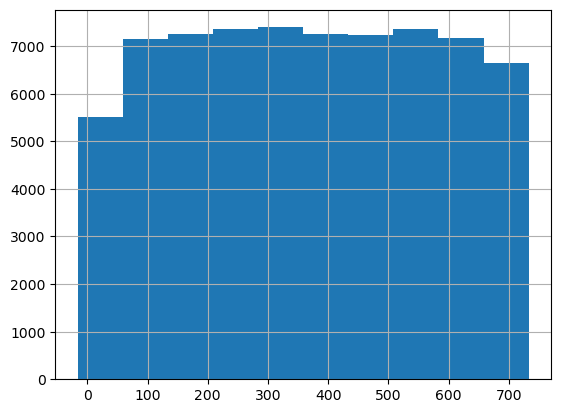

In [ ]:
# En el histograma observamos tiempos bastante regulares para cada bin pero llama la atención los valores inferiores a 0
df_venta_en_cliente["tiempo_venta"].hist(bins=10)

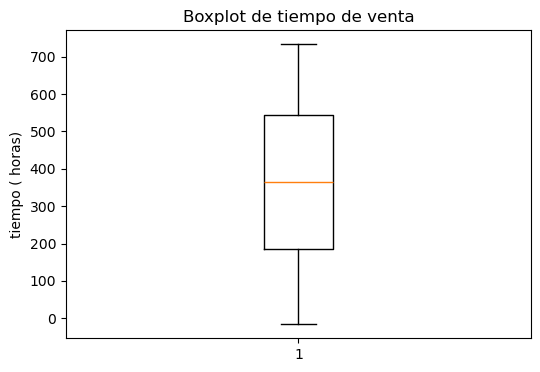

In [ ]:
#Visualizamos un boxplot para ver las distribución
plt.figure(figsize=(6,4))
plt.boxplot(df_venta_en_cliente["tiempo_venta"].dropna())
plt.title("Boxplot de tiempo de venta")
plt.ylabel("tiempo ( horas)")
plt.show()

In [ ]:
# Filtramos por la columna tiempo_venta y buscamos lo valores inferiores a 0.El valor tiempo en negativo hay que mirar el motivo. Tenemos 508 valores igual a 0 o inferior a 0
df_venta_en_cliente[df_venta_en_cliente["tiempo_venta"] <=0].count()

t_id            508
tiempo_venta    508
precio_venta    503
peso            508
cliente         508
dtype: int64

<Axes: >

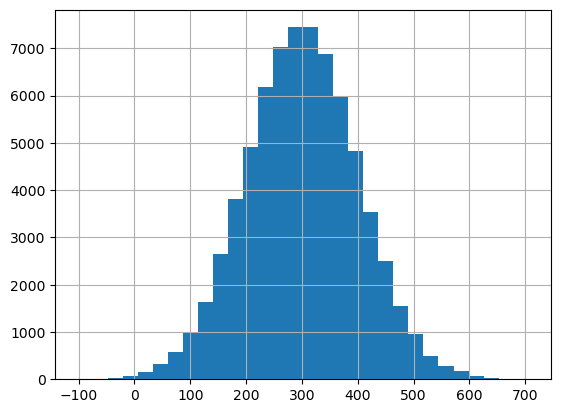

In [ ]:
# Observamos valores inferiores a 0 en un peso
df_venta_en_cliente["peso"].hist(bins=30)

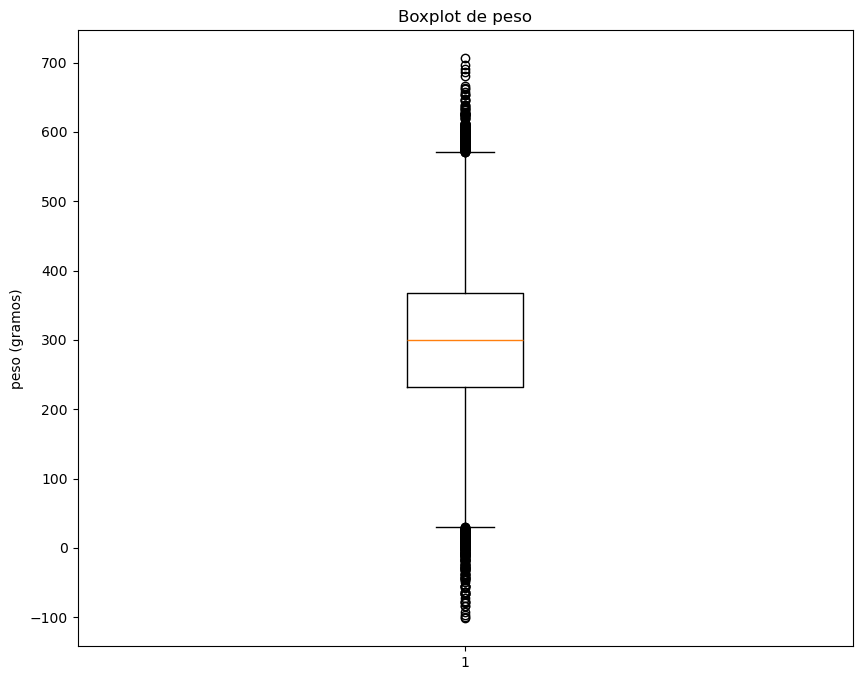

In [ ]:
#Visualizamos un boxplot para ver las distribución
plt.figure(figsize=(10,8))
plt.boxplot(df_venta_en_cliente["peso"].dropna())
plt.title("Boxplot de peso")
plt.ylabel("peso (gramos)")
plt.show()

In [ ]:
# Misma situación filtramos por la columna peso y obtenemos 113 valores igual a 0 o inferior a 0. Esto podría deberse a un fallo de la báscula pero no esta confirmado
df_venta_en_cliente[df_venta_en_cliente["peso"] <= 0].count()

t_id            113
tiempo_venta    113
precio_venta    112
peso            113
cliente         113
dtype: int64

<Axes: >

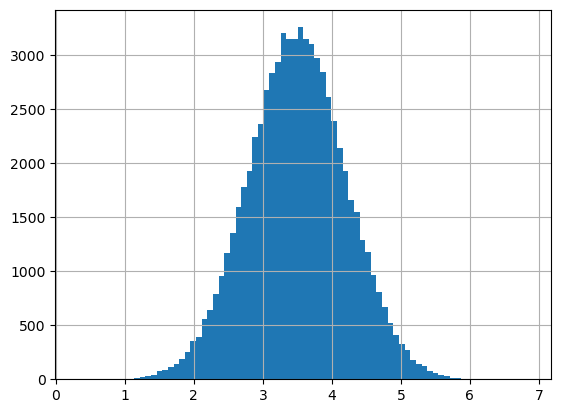

In [ ]:
# Ploteo un histograma para observar los valores de las colas y apenas los puedo ver
df_venta_en_cliente["precio_venta"].hist(bins=80)


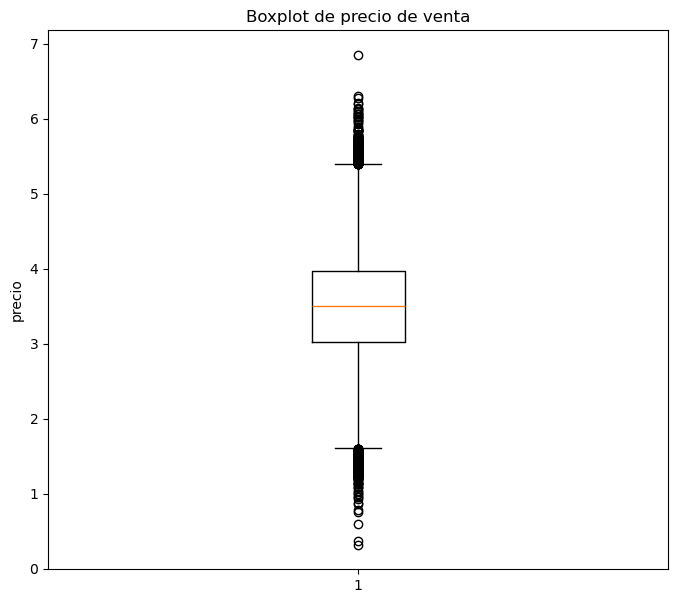

In [ ]:
#Visualizamos un boxplot para ver las distribución
plt.figure(figsize=(8,7))
plt.boxplot(df_venta_en_cliente["precio_venta"].dropna())
plt.title("Boxplot de precio de venta")
plt.ylabel("precio")
plt.show()

In [ ]:
# Como consecuencia del histograma anterior filtro pero el precio de venta inferior a 1 y observo 11 valores. Que se podrian deber a la ley de la oferta y la demanda
df_venta_en_cliente[df_venta_en_cliente["precio_venta"] < 1].head(11)

,t_id,tiempo_venta,precio_venta,peso,cliente
3012,Guava01680.png,99.0,0.368303,371.824832,La Tienda Justa
4634,Carambola 00630.png,514.0,0.955894,372.694980,Supermercados del Valle
11164,GuavaÒÇé2226 resized.jpg,289.0,0.775458,275.840928,Tienda Selecta
17898,Kiwi001549.png,242.0,0.317017,364.186988,Alimentación Total
28220,Kiwi00482.png,245.0,0.755437,48.147079,SuperAhorro Express
40609,Kiwi A0052.png,160.0,0.996291,209.440076,Distribuciones del Sol
46685,GuavaÒÇé655 resized.jpg,240.0,0.951164,273.535126,SuperOfertas Plus
49406,Peach001088.png,187.0,0.879849,360.214683,Distribuidora Gourmet
60775,1GuavaÒÇé2981 resized.png,669.0,0.923201,318.227333,SuperValle Verde
61143,Guava02295.png,536.0,0.864333,143.899426,SuperValle Verde


In [ ]:
# Describe de las columnas catégoricas
df_venta_en_cliente[['t_id', 'cliente']].describe()

,t_id,cliente
count,70549,70549
unique,69687,34
top,scene01001.png,SuperMercado Ideal
freq,5,2129


In [ ]:
#CONCLUSIÓN
# TENEMOS UN DATEFRAME DE 5 COLUMNAS Y 70549 FILAS.
# NULOS TENEMOS 223 EN LA COLUMNA tiempo_venta Y 694 EN LA COLUMNA precio_venta
# SOBRE DUPLICADOS MANTENEMOS LA MISMA CANTIDAD EN LA COLUMNA t_id (862) Y LA COLUMNA CLIENTE TIENE 34 VALORES ÚNICOS. EL RESTO DE COLUMNAS SON NÚMERICAS
# POR LO TANTO HAY DUPLICADOS EN ALGUNAS.
# OBSERVAMOS EL DESCRIBE DE COLUMNAS NÚMERICAS Y OBSERVAMOS:
# COLUMNA tiempo_venta: El valor tiempo en negativo hay que mirar el motivo. Tenemos 508 valores igual a 0 o inferior a 0
# COLUMNA peso:  obtenemos 113 valores igual a 0 o inferior a 0. Esto podría deberse a un fallo de la báscula pero no esta confirmado.
# COLUMNA precio_venta TIENE ALGUNOS OUTLIERS TANTO EN MIN COMO EN MAX PERO PODRIA DEBERSE A LA LEY DE LA OFERTA Y LA DEMANDA EN ESE MOMENTO




In [ ]:
conda update python

Retrieving notices: ...working... done
Channels:
 - defaults
 - conda-forge
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
